# Qamomile v0.10.0

Qamomile v0.10.0 is a ground-up rebuild of the quantum programming layer. This enables Qamomile to cover not only quantum optimization algorithm development — its original scope — but also general-purpose quantum program and algorithm development. The amount of changes from v0.9.0 is massive, so rather than listing what changed, this page describes **what v0.10.0 can do**.

See the [tutorials](../tutorial) for more details.
```
pip install qamomile==0.10.0
````

## Frontend: `@qkernel`

The central API for writing quantum programs in Qamomile v0.10.0 is the `@qkernel` decorator. You write a normal Python function with **type-annotated** arguments and return values, and Qamomile traces it into an intermediate representation (IR) that can be analyzed, visualized, and transpiled. You don't need to interact with the IR directly. Classical control flow such as `for`/`while` loops and `if` statements is also supported and traced into the IR.

The rules you must follow when writing a `@qkernel` are:

- **Type hints are required.** Arguments and return types primarily use Qamomile's types: `Qubit`, `Bit`, `Float`, `UInt`, `Vector[T]`, `Dict[K, V]`, `Tuple[...]`.
- **Affine typing for qubits.** A `Qubit` handle must be reassigned after every gate (`q = qmc.h(q)`).

Available gates include H, X, Y, Z, S, T, RX, RY, RZ, RZZ, CX, CZ, CCX, CP, SWAP, and more. Measurement is done with `qmc.measure()`.

In [1]:
import qamomile.circuit as qmc


@qmc.qkernel
def ghz_state(
    n: qmc.UInt,
) -> qmc.Vector[qmc.Bit]:  # Type hints for arguments and return type
    q = qmc.qubit_array(
        n, name="q"
    )  # Allocate an array of n qubits with the given size and name

    q[0] = qmc.h(q[0])
    for i in qmc.range(1, n):  # Iterate over qubits 1 to n-1 using qmc.range
        q[0], q[i] = qmc.cx(q[0], q[i])

    return qmc.measure(q)

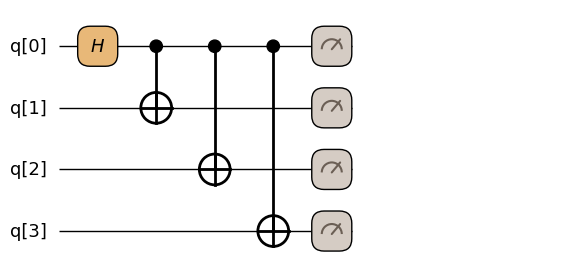

In [2]:
ghz_state.draw(n=4, fold_loops=False)

Related tutorials: [Your First Quantum Kernel](../tutorial/your-first-quantum-kernel), [Parameterized Quantum Kernels](../tutorial/parameterized-kernels), [Execution Models: sample() vs run()](../tutorial/execution-models), [Reuse Patterns: QKernel Composition and Composite Gates](../tutorial/reuse-patterns)

## Resource Estimation

Qamomile v0.10.0 provides symbolic resource estimation. Call `estimate_resources()` on any qkernel to get qubit counts and gate breakdowns **without executing** the qkernel. These estimates are symbolic expressions in terms of the input parameters, so you can analyze how resources scale with problem size. You can also substitute specific values to get concrete estimates for a given input size. Furthermore, you can define implementation-free black-box oracles using the `@composite_gate` decorator with `stub=True`, and resource estimation is possible for qkernels that use them.

In [3]:
est = ghz_state.estimate_resources()
print("qubits:", est.qubits)
print("total two-qubit gates:", est.gates.two_qubit)

qubits: n
total two-qubit gates: n - 1


In [4]:
# Evaluate at a specific size
print("two-qubit gates at n=100:", est.substitute(n=100).gates.two_qubit)

two-qubit gates at n=100: 99


Related tutorials: [Resource Estimation](../tutorial/resource-estimation), [Reuse Patterns: QKernel Composition and Composite Gates](../tutorial/reuse-patterns)

## Multi-Quantum SDK Transpilation

Define your circuit once with `@qkernel`, then transpile to any supported quantum SDK. The transpiled qkernel becomes an `ExecutableProgram` for the target quantum SDK. Qamomile v0.10.0 includes preset executors for each quantum SDK, so you can execute without writing any target SDK code. These preset executors assume simulator execution. You can also create custom executors for finer control and access to actual quantum hardware.

| Backend | Module | Transpiler | Default Execution |
|---------|--------|-----------|-----------|
| Qiskit | `qamomile.qiskit` | `QiskitTranspiler` | Local simulator |
| QURI Parts | `qamomile.quri_parts` | `QuriPartsTranspiler` | Local simulator |
| CUDA-Q | `qamomile.cudaq` | `CudaqTranspiler` | Local simulator |

Furthermore, for Qiskit, [qBraid](https://docs.qbraid.com/) execution is supported, enabling execution on cloud quantum devices.

Qiskit is included by default with `pip install qamomile`, but other quantum SDKs and qBraid execution require optional extra packages:

```bash
pip install "qamomile[cudaq-cu12]"   # CUDA-Q with CUDA 12.x (Linux)
pip install "qamomile[cudaq-cu13]"   # CUDA-Q with CUDA 13.x (Linux / macOS ARM64)
pip install "qamomile[quri_parts]"   # QURI Parts
pip install "qamomile[qbraid]"       # qBraid integration for Qiskit
```

In [5]:
from qamomile.qiskit import QiskitTranspiler

qiskit_transpiler = QiskitTranspiler()
qiskit_executable = qiskit_transpiler.transpile(ghz_state, bindings={"n": 4})
samples = qiskit_executable.sample(
    qiskit_transpiler.executor(),  # Specify the executor to run on
    shots=1024,
).result()

for outcome, count in samples.results:
    print(f"  outcome={outcome}, count={count}")

  outcome=(0, 0, 0, 0), count=511
  outcome=(1, 1, 1, 1), count=513


Related tutorials: [Execution Models: sample() vs run()](../tutorial/execution-models), [qBraid Support - QBraidExecutor](../collaboration/qbraid-executor)

## Standard Library

To help users write quantum algorithms easily, Qamomile v0.10.0 provides built-in algorithms in the `qmc.stdlib` and `qmc.algorithm` modules, including Quantum Fourier Transform (QFT), Quantum Phase Estimation (QPE), Quantum Approximate Optimization Algorithm (QAOA), and more. `qmc.stdlib` contains broadly used basic algorithm blocks, while `qmc.algorithm` contains more specialized algorithms; however, these categorizations are not strict and may change between releases.

We will keep on adding more algorithms to those modules, so stay tuned!

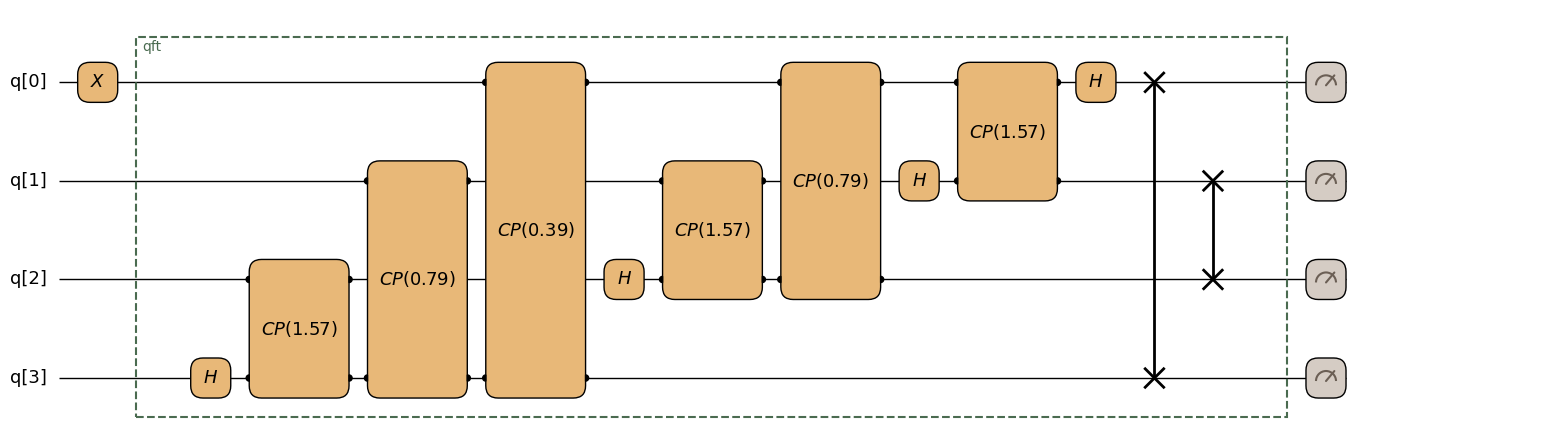

In [6]:
from qamomile.circuit.stdlib import qft


@qmc.qkernel
def qft_example() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(4, name="q")
    q[0] = qmc.x(q[0])
    q = qft(q)
    return qmc.measure(q)


qft_example.draw(expand_composite=True)

## Optimization Converters

The converters from v0.9.0 are available under `qamomile.optimization`, rewritten to use the new `@qkernel`-based circuit layer.
They take a mathematical model (via [JijModeling](https://www.documentation.jijzept.com/docs/jijmodeling/) or OMMX) and produce a ready-to-run circuit.

## Learn More
- [Tutorials](../tutorial)
- [GitHub Repository](https://github.com/Jij-Inc/Qamomile)